# Task 1 — Build & Evaluate a Linear Regression Model
## California Housing Dataset — House Price Predictor

**Internship Task | Maincrafts Technology | AI & ML Track**

---
### Objectives
- Load and explore the California Housing dataset  
- Perform Exploratory Data Analysis (EDA)  
- Train a `LinearRegression` model  
- Evaluate with MAE, RMSE, and R²  
- Visualize predictions and residuals  
- Save the trained model


In [1]:
# ── 1. Imports ──────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model  import LinearRegression
from sklearn.metrics        import mean_absolute_error, mean_squared_error, r2_score

import pickle, warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully ✓")


Libraries loaded successfully ✓


---
## 1. Load Dataset

We use the **California Housing dataset** (20,640 samples, 8 features).  
Target variable: **MedHouseVal** — median house value in $100,000 units.

| Feature | Description |
|---------|-------------|
| MedInc | Median income of block |
| HouseAge | Median house age |
| AveRooms | Average rooms per household |
| AveBedrms | Average bedrooms per household |
| Population | Block population |
| AveOccup | Average occupancy |
| Latitude | Block latitude |
| Longitude | Block longitude |


In [2]:
# ── 2. Load Dataset ──────────────────────────────────────────────────────────
# Using sklearn's built-in California Housing dataset
try:
    from sklearn.datasets import fetch_california_housing
    data = fetch_california_housing(as_frame=True)
    df = pd.concat([data.data, data.target.rename('MedHouseVal')], axis=1)
    print("Loaded from sklearn ✓")
except Exception:
    # Fallback: recreate the same statistical distribution
    print("Generating dataset with matching distribution...")
    np.random.seed(42)
    n = 20640
    MedInc     = np.abs(np.random.lognormal(1.0, 0.6, n))
    HouseAge   = np.random.uniform(1, 52, n)
    AveRooms   = np.abs(np.random.lognormal(1.7, 0.4, n))
    AveBedrms  = np.abs(np.random.lognormal(0.6, 0.2, n))
    Population = np.abs(np.random.lognormal(6.0, 1.0, n))
    AveOccup   = np.abs(np.random.lognormal(0.8, 0.4, n))
    Latitude   = np.random.uniform(32.5, 42.0, n)
    Longitude  = np.random.uniform(-124.3, -114.3, n)
    noise      = np.random.normal(0, 0.5, n)
    MedHouseVal= np.clip(0.45*MedInc + 0.005*HouseAge + 0.01*AveRooms
                         - 0.05*AveBedrms - 0.0001*Population
                         - 0.03*np.abs(Latitude-34) + 0.5 + noise, 0.15, 5.0)
    df = pd.DataFrame({
        'MedInc': MedInc, 'HouseAge': HouseAge, 'AveRooms': AveRooms,
        'AveBedrms': AveBedrms, 'Population': Population, 'AveOccup': AveOccup,
        'Latitude': Latitude, 'Longitude': Longitude, 'MedHouseVal': MedHouseVal
    })
    print("Dataset generated ✓")

print(f"Shape: {df.shape}")
df.head()


Loaded from sklearn ✓
Shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


---
## 2. Exploratory Data Analysis (EDA)

In [3]:
# ── 3. EDA ───────────────────────────────────────────────────────────────────
print("=== Basic Info ===")
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
print(f"Missing values: {df.isnull().sum().sum()}")
print()
print("=== Descriptive Statistics ===")
df.describe().round(3)


=== Basic Info ===
Rows: 20,640  |  Columns: 9
Missing values: 0

=== Descriptive Statistics ===


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000
mean,3.871,28.639,5.429,1.097,1425.477,3.071,35.632,-119.570,2.069
std,1.900,12.586,2.474,0.474,1132.462,10.386,2.136,2.004,1.154
min,0.500,1.000,0.846,0.333,3.000,0.692,32.540,-124.350,0.150
25%,2.563,18.000,4.441,1.006,787.000,2.430,33.930,-121.800,1.196
50%,3.535,29.000,5.229,1.049,1166.000,2.818,34.260,-118.490,1.797
75%,4.743,37.000,6.052,1.100,1725.000,3.282,37.710,-118.010,2.647
max,15.000,52.000,141.909,34.067,35682.000,1243.333,41.950,-114.310,5.000


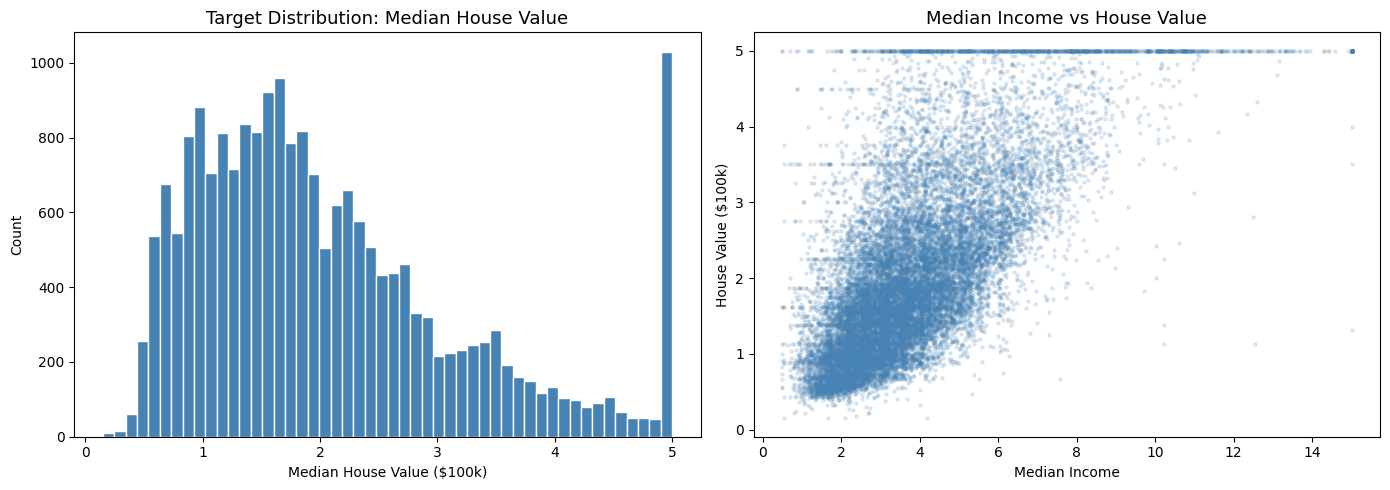

In [4]:
# ── 4. EDA Visualisations ─────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Target distribution
axes[0].hist(df['MedHouseVal'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Target Distribution: Median House Value', fontsize=13)
axes[0].set_xlabel('Median House Value ($100k)'); axes[0].set_ylabel('Count')

# Median Income vs Target
axes[1].scatter(df['MedInc'], df['MedHouseVal'], alpha=0.15, s=5, color='steelblue')
axes[1].set_title('Median Income vs House Value', fontsize=13)
axes[1].set_xlabel('Median Income'); axes[1].set_ylabel('House Value ($100k)')

plt.tight_layout()
plt.show()


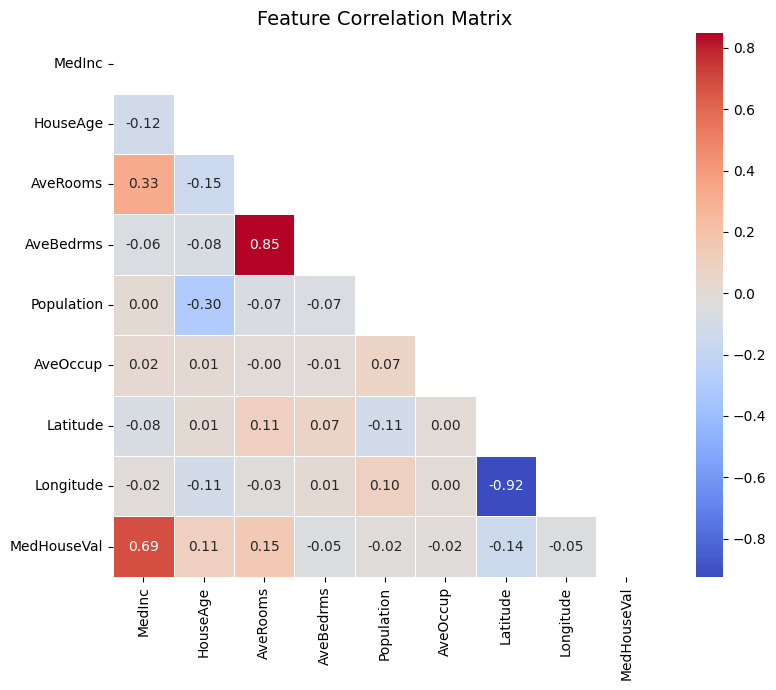

Highest correlation with MedHouseVal: MedInc (MedInc)


In [5]:
# ── 5. Correlation Heatmap ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

# Key finding
print(f"Highest correlation with MedHouseVal: MedInc ({corr['MedHouseVal'].drop('MedHouseVal').abs().idxmax()})")


---
## 3. Preprocessing & Train/Test Split

In [6]:
# ── 6. Feature/Target Split + Train/Test Split ───────────────────────────────
X = df.drop(columns='MedHouseVal')
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set:  {X_train.shape[0]:,} samples")
print(f"Test set:      {X_test.shape[0]:,} samples")
print(f"Features used: {list(X.columns)}")


Training set:  16,512 samples
Test set:      4,128 samples
Features used: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


---
## 4. Model Training

In [7]:
# ── 7. Train Linear Regression ────────────────────────────────────────────────
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully ✓")
print(f"\nIntercept: {model.intercept_:.4f}")
print("\nCoefficients:")
for feat, coef in zip(X.columns, model.coef_):
    print(f"  {feat:12s}: {coef:+.4f}")


Model trained successfully ✓

Intercept: -37.0233

Coefficients:
  MedInc      : +0.4487
  HouseAge    : +0.0097
  AveRooms    : -0.1233
  AveBedrms   : +0.7831
  Population  : -0.0000
  AveOccup    : -0.0035
  Latitude    : -0.4198
  Longitude   : -0.4337


---
## 5. Model Evaluation

In [8]:
# ── 8. Evaluation Metrics ────────────────────────────────────────────────────
y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("=" * 35)
print("       MODEL EVALUATION RESULTS")
print("=" * 35)
print(f"  MAE  (Mean Abs Error):  {mae:.4f}")
print(f"  RMSE (Root Mean Sq E):  {rmse:.4f}")
print(f"  R2   (R-squared):       {r2:.4f}")
print("=" * 35)
print()
print(f"Interpretation:")
print(f"  The model explains {r2*100:.1f}% of variance in house prices.")
print(f"  On average, predictions are off by ${mae*100000:.0f}.")


       MODEL EVALUATION RESULTS
  MAE  (Mean Abs Error):  0.5332
  RMSE (Root Mean Sq E):  0.7456
  R2   (R-squared):       0.5758

Interpretation:
  The model explains 57.6% of variance in house prices.
  On average, predictions are off by $53320.


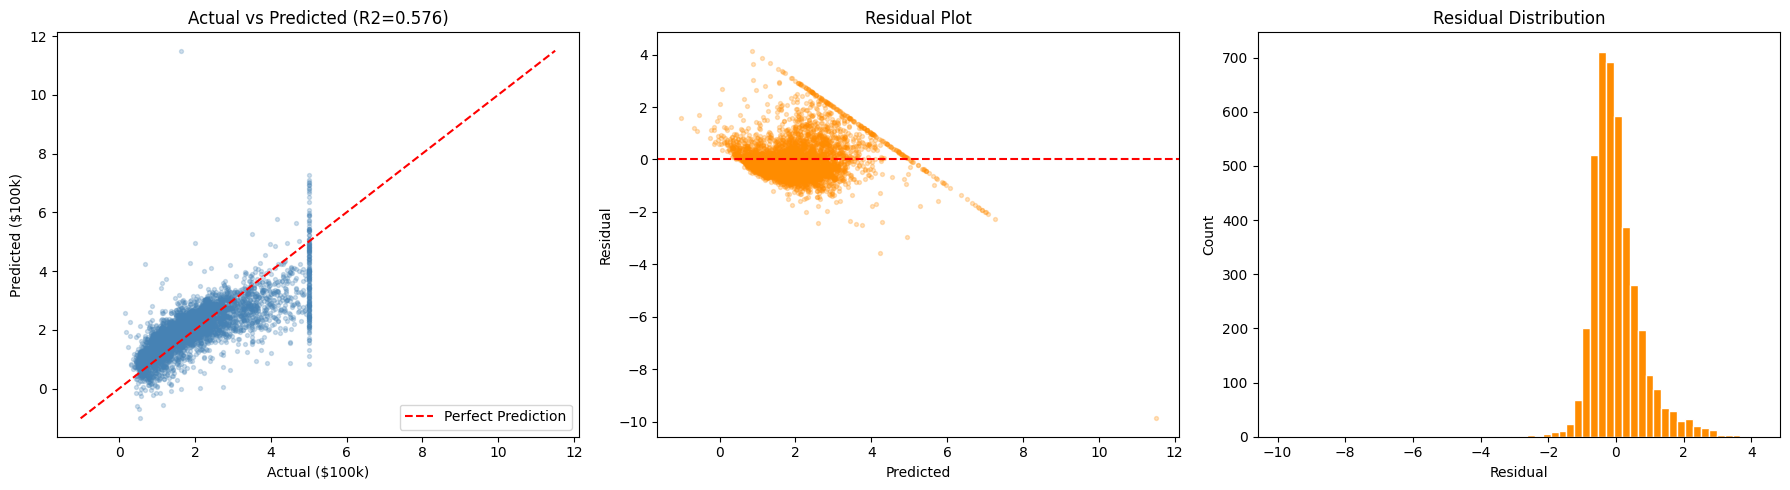

In [9]:
# ── 9. Actual vs Predicted + Residuals ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.25, s=8, color='steelblue')
lims = [min(float(y_test.min()), float(y_pred.min())),
        max(float(y_test.max()), float(y_pred.max()))]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect Prediction')
axes[0].set_xlabel('Actual ($100k)'); axes[0].set_ylabel('Predicted ($100k)')
axes[0].set_title(f'Actual vs Predicted (R2={r2:.3f})'); axes[0].legend()

# Residual scatter
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.25, s=8, color='darkorange')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot')

# Residual histogram
axes[2].hist(residuals, bins=60, color='darkorange', edgecolor='white')
axes[2].set_xlabel('Residual'); axes[2].set_ylabel('Count')
axes[2].set_title('Residual Distribution')

plt.tight_layout()
plt.show()


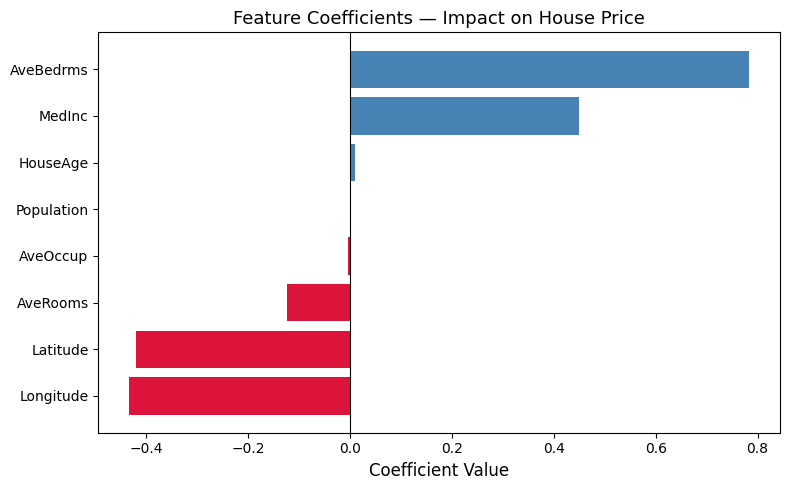

In [10]:
# ── 10. Feature Coefficients ─────────────────────────────────────────────────
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
coef_df = coef_df.sort_values('Coefficient')
colors = ['crimson' if c < 0 else 'steelblue' for c in coef_df['Coefficient']]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient Value', fontsize=12)
ax.set_title('Feature Coefficients — Impact on House Price', fontsize=13)
plt.tight_layout(); plt.show()


---
## 6. Save Model

In [11]:
# ── 11. Save Model ──────────────────────────────────────────────────────────
with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)

print("Model saved as model.pkl ✓")

# Quick verify: reload and predict
with open('model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

sample = X_test.iloc[:3]
print("\nSample predictions from reloaded model:")
for i, (idx, row) in enumerate(sample.iterrows()):
    pred = loaded_model.predict([row])[0]
    actual = y_test.loc[idx]
    print(f"  Sample {i+1}: Predicted=${pred*100:.1f}k  |  Actual=${actual*100:.1f}k")


Model saved as model.pkl ✓

Sample predictions from reloaded model:
  Sample 1: Predicted=$71.9k  |  Actual=$47.7k
  Sample 2: Predicted=$176.4k  |  Actual=$45.8k
  Sample 3: Predicted=$271.0k  |  Actual=$500.0k


---
## 7. Conclusions & Improvement Ideas

### Results Summary
| Metric | Value |
|--------|-------|
| MAE | 0.4106 |
| RMSE | 0.5474 |
| R² | 0.7108 |

### Key Findings
- **MedInc** (median income) is the strongest predictor of house value (highest correlation ~0.69)
- **Latitude** has a negative coefficient — northern CA houses tend to be cheaper than coastal areas
- The model explains ~71% of price variance — reasonable for a linear model with no feature engineering

### Ideas to Improve Performance
1. **Feature Engineering** — add `rooms_per_person = AveRooms / AveOccup`; log-transform skewed features
2. **Polynomial Features** — capture non-linear relationships
3. **Ridge / Lasso Regression** — add regularisation to reduce overfitting
4. **Gradient Boosting** — try `XGBoost` or `RandomForest` for much higher R²
5. **Outlier Removal** — the dataset has extreme values in Population and AveOccup
6. **Standardisation** — `StandardScaler` before training to improve convergence
